In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import RichProgressBar, Timer, LearningRateFinder
import omegaconf
from loguru import logger


# Add the prime_torch file to the system path so we can import it
import sys
# sys.path.append("/glade/u/home/cobrien/prime/prime_lib/primesw")
# from data import SWDataset, SWDataModule
# from prime_torch import crps, SWRegressor, load
import primesw

In [2]:
model = primesw.load('PRIME')

In [3]:
model.predict_ts(start = '2020-01-01 00:00:00', stop = '2020-01-05 00:00:00')

,Epoch,mms1_dis_bulkv_gse_fast_0,mms1_dis_bulkv_gse_fast_0_std,mms1_dis_bulkv_gse_fast_1,mms1_dis_bulkv_gse_fast_1_std,mms1_dis_bulkv_gse_fast_2,mms1_dis_bulkv_gse_fast_2_std,mms1_des_numberdensity_fast,mms1_des_numberdensity_fast_std,mms1_fgm_b_gse_srvy_l2_0,mms1_fgm_b_gse_srvy_l2_0_std,mms1_fgm_b_gse_srvy_l2_1,mms1_fgm_b_gse_srvy_l2_1_std,mms1_fgm_b_gse_srvy_l2_2,mms1_fgm_b_gse_srvy_l2_2_std
150,2020-01-01 05:13:20+00:00,-309.664612,25.193054,43.320438,10.483765,11.857665,6.572339,7.922668,1.780308,2.998601,1.458619,-1.115229,2.562944,0.470261,1.309801
151,2020-01-01 05:15:00+00:00,-308.720276,25.257141,42.833687,10.480705,11.792150,6.478621,7.924119,1.784341,3.041475,1.415620,-1.135831,2.546472,0.415693,1.293574
152,2020-01-01 05:16:40+00:00,-308.053101,25.654877,42.776817,10.320732,11.979615,6.508096,7.725145,1.740165,3.073807,1.385049,-1.117593,2.479419,0.287956,1.224914
153,2020-01-01 05:18:20+00:00,-309.546143,24.965729,42.395756,10.120487,11.641371,6.372860,7.685886,1.756714,3.014476,1.369563,-1.259596,2.420860,0.229840,1.194227
154,2020-01-01 05:20:00+00:00,-308.491089,25.296753,42.747482,10.071487,11.391092,6.380161,7.464390,1.703540,2.994136,1.284742,-1.237498,2.338008,0.132431,1.136126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,2020-01-05 00:50:00+00:00,-328.323639,29.396332,10.511005,11.780268,-4.633298,7.647037,5.119274,1.727790,3.216998,1.447995,-5.747725,1.362864,-4.706904,1.132837
3390,2020-01-05 00:51:40+00:00,-328.799255,29.702271,10.692627,11.781387,-4.367133,7.688503,5.054473,1.709865,3.178624,1.411445,-5.716502,1.362267,-4.666988,1.144839
3391,2020-01-05 00:53:20+00:00,-329.406677,30.090210,10.198634,11.834374,-4.478115,7.725025,5.091926,1.744716,3.175910,1.452307,-5.788320,1.373118,-4.663342,1.095733
3392,2020-01-05 00:55:00+00:00,-331.843323,29.977081,9.494118,11.677359,-4.530295,7.548120,5.010997,1.724300,3.132260,1.411343,-5.847035,1.352967,-4.610333,1.088033


In [ ]:
torch.set_float32_matmul_precision('medium')

config = '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_strict.yaml'
cfg = omegaconf.OmegaConf.load(
    config
)
datamodule = primesw.data.SWDataModule(
    target_features = cfg.data.target_features,
    input_features = cfg.data.input_features,
    position_features = cfg.data.position_features,
    interp_flags = cfg.data.interp_flags,
    region = cfg.data.region,
    cuts = cfg.data.cuts,
    cadence = cfg.data.cadence,
    interpolate = cfg.data.interpolate,
    window = cfg.data.window,
    stride = cfg.data.stride,
    interp_frac = cfg.data.interp_frac,
    trn_bounds = ['20150822 02:55:00+0000', '20150824 02:55:00+0000'],#cfg.data.trn_bounds,
    val_bounds = ['20150822 02:55:00+0000', '20150824 02:55:00+0000'],# cfg.data.val_bounds,
    tst_bounds = cfg.data.tst_bounds,
    batch_size = cfg.opt.batch_size,
    num_workers = cfg.opt.num_workers,
    datastore = cfg.data.datastore,
    in_key = cfg.data.in_key,
    tar_key = cfg.data.tar_key,
    scaler_type = cfg.data.scaler_type,
)
# datamodule.setup()

model = primesw.prime_torch.SWRegressor.load_from_checkpoint(
    "/glade/u/home/cobrien/data/prime/tensorboard_logs/psstrict/version_6/checkpoints/epoch=299-step=16500.ckpt" # TODO Just use this plasmasheet checkpoint for making the grid prediction code while the new version of PRIME trains. Delete ASAP
    # "/glade/u/home/cobrien/data/prime/tensorboard_logs/canon/version_2/checkpoints/epoch=199-step=7400.ckpt"
)
model.eval() # Disables randomness, dropout, gradients

In [3]:
# Load the data
wind_data = pd.read_hdf('/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5', key = 'wind_full', mode = 'r')

# Make the positions dataframe
t0 = pd.to_datetime("2018-10-06 22:00:00+0000")
t1 = pd.to_datetime("2018-10-07 04:00:00+0000")
wind_data = wind_data.loc[
    (wind_data['Epoch'] <= t1 - pd.Timedelta(seconds = (model.stride) * 100))&
    (wind_data['Epoch'] >= t0 - pd.Timedelta(seconds = (model.stride + model.window) * 100)),
    :
]
positions = pd.DataFrame(wind_data['Epoch'], columns = ['Epoch'])
positions['Rx_int'] = 13.25 * np.ones(len(positions)) # Set the default position to a notional bow shock nose
positions['Ry_int'] = 0.0   * np.ones(len(positions))
positions['Rz_int'] = 0.0   * np.ones(len(positions))

In [ ]:
def predict_grid(
    model, # TODO replace with 'self' when inserting into SWRegressor()
    ts,
    gridsize,
    x_extent,
    y_extent=None,
    z_extent=None,
    y = 0,
    z = 0,
    loc_mask=None,
    subtract_ecliptic=False,
):
    """
    Generate predictions from prime model on a grid of points.

    Parameters:
        ts (DataFrame): Timeseries of data at L1 (Can be synthetic)
        gridsize (float): Spacing of grid points
        x_extent (list): Range of x values to calculate on
        y_extent (list): Range of y values to calculate on. If None, z_extent must be specified.
        z_extent (list): Range of z values to calculate on. If None, y_extent must be specified.
        y (float, array-like): Y position that is held constant if y_extent is not specified. Default 0.
        z (float, array-like): Z position that is held constant if z_extent is not specified. Default 0.
        loc_mask (float, optional): RE from Earth to occlude (masking the magnetopause/magnetosheath)
    Returns:
        output_grid (ndarray): Array of predicted values on the grid. Shape (timestamps, x_extent/gridsize, y_extent/gridsize, features * 2)
        timestamps (Series): Series of datetimes corresponding to each grid's time
    """
    # Generate the embeddings from the timeseries
    in_scaled = ts.loc[:, model.in_norm.keys()].copy() # Get just the keys used for prediction
    for feature in model.in_norm.keys(): # Scale each input feature DOWN
        in_scaled[feature] = (in_scaled[feature] - model.in_norm[feature][0])/model.in_norm[feature][1]
    in_arr = np.zeros((len(in_scaled) - model.window, model.window, len(model.in_norm.keys()))) # Prepare the input array in the shape the encoder expects
    for i, idx in enumerate(in_scaled.index): # Fill each segment with input data
        if i < model.window:
            continue
        in_arr[i - model.window, :, :] = in_scaled.loc[(idx - model.window - model.stride):(idx - model.stride - 1), :]
    in_tensor = torch.from_numpy(in_arr.astype(np.float32)).to(model.device) # Make sure the inputs are on the same device as the model
    logger.info("Timeseries tensor created.")
    embeddings, h = model.encoder.forward(in_tensor) # Generate the embeddings (1 forward pass)
    logger.info("Embeddings created.")

    # Create the grid based on the extent and gridsize specs
    x_arr = np.arange(x_extent[0], x_extent[1], gridsize)  # Create a grid to calculate the magnetosheath conditions on
    y_arr = np.asarray([y]) # This array is overwritten if y_extent is specified
    z_arr = np.asarray([z]) # This array is overwritten if z_extent is specified
    if y_extent is None and z_extent is None:
        raise ValueError("Must specify y_extent or z_extent")
    if y_extent is not None:
        y_arr = np.arange(y_extent[0], y_extent[1], gridsize)  # Y positions to calculate the magnetosheath conditions on
    if z_extent is not None:
        z_arr = np.arange(z_extent[0], z_extent[1], gridsize)  # Z positions to calculate the magnetosheath conditions on
    x_grid, y_grid, z_grid = np.meshgrid(x_arr, y_arr, z_arr)  # Create a grid to calculate the magnetosheath conditions on
    logger.info("Grid created.")
    
    # Make the ultralong position tensor
    steps = len(embeddings)
    pos_arr = np.zeros((len(x_grid.flatten()) * steps, 3))  # Initialize array to hold the position data
    pos_arr[:, 0] = np.tile(x_grid.flatten(), steps)
    pos_arr[:, 1] = np.tile(y_grid.flatten(), steps)
    pos_arr[:, 2] = np.tile(z_grid.flatten(), steps)
    for i, feature in enumerate(model.pos_norm.keys()): # Scale each position feature DOWN
        pos_arr[:, i] = (pos_arr[:, i] - model.pos_norm[feature][0])/model.pos_norm[feature][1]
    pos_tensor = torch.from_numpy(pos_arr.astype(np.float32)).to(model.device) # Make sure the positions are on the same device as the model
    logger.info("Position tensor created.")

    # Extend embeddings to match the size of the position tensor
    embeddings = embeddings.repeat_interleave(len(x_grid.flatten()), dim = 0) #NOTE: Torch repeat_interleave() works like numpy repeat()
    logger.info("Embeddings extended.")
    
    # Run a forward pass on the ultralong tensors and rescale the outputs to human units
    y_hat = model.decoder(embeddings, pos_tensor) # Run an actual forward pass
    logger.info("Decoder forward pass complete.")
    y_hat = y_hat.detach().cpu().numpy()
    logger.info("Outputs moved to CPU.")
    output_raveled = np.empty(y_hat.shape)
    if y_hat.shape[1] == 2*len(model.tar_norm.keys()): # If the output is means + stdevs
        for i, feature in enumerate(model.tar_norm.keys()):
            output_raveled[:, i*2] = (y_hat[:, i*2] * model.tar_norm[feature][1]) + model.tar_norm[feature][0]
            output_raveled[:, i*2 +1 ] = ((y_hat[:, i*2] + y_hat[:, i*2 + 1]) * model.tar_norm[feature][1]) + model.tar_norm[feature][0] - output_raveled[:, i*2]
    else:
        for i, feature in enumerate(self.tar_norm.keys()):
            output_raveled[:, i]  = (y_hat[:, i] * self.tar_norm[feature][1]) + self.tar_norm[feature][0]
    logger.info("Outputs rescaled.")

    # Reshape the output data to transform it back to the grid
    output_grid = output_raveled.reshape(steps, len(y_arr), len(x_arr), len(z_arr), y_hat.shape[1])  # Reshape the output data into the correct shape
    output_grid = np.swapaxes(output_grid, 1, 2)  # Move the y axis to the second axis (new order is frame, x, y, z, param)
    if loc_mask is not None:
        r_grid = np.swapaxes(np.sqrt(x_grid**2 + y_grid**2 + z_grid**2), 0, 1) # radial distance to origin at all grid points
        output_mask = np.zeros(output_grid.shape, dtype=bool)  # Initialize array to hold the frame mask
        # # Make a mask for all points outside the bow shock or inside the magnetopause
        for i in np.arange(steps):
            for j in np.arange(output_grid.shape[-1]):
                output_mask[i, :, : , :, j] = (r_grid < loc_mask)
        # Make a masked version of the output grid
        output_grid = np.ma.masked_array(output_grid, mask=output_mask)
    return output_grid

: 

In [4]:
# MAke a movie of the solar wind conditions on the Noodle day event

# Define the grid extent
gridsize = 1
x_extent = [-30, 0]
y_extent = [-15, 15]
z_extent = None
y = 0
z = 0
loc_mask = None # Cut out this many RE from Earth where the outputs are invalid
ts = wind_data

# output_grid = predict_grid(model, wind_data, gridsize, x_extent, y_extent=y_extent, z_extent=z_extent, y = y, z = z, loc_mask = loc_mask)
in_scaled = ts.loc[:, model.in_norm.keys()].copy() # Get just the keys used for prediction
for feature in model.in_norm.keys(): # Scale each input feature DOWN
    in_scaled[feature] = (in_scaled[feature] - model.in_norm[feature][0])/model.in_norm[feature][1]
in_arr = np.zeros((len(in_scaled) - model.window, model.window, len(model.in_norm.keys()))) # Prepare the input array in the shape the encoder expects
for i, idx in enumerate(in_scaled.index): # Fill each segment with input data
    if i < model.window:
        continue
    in_arr[i - model.window, :, :] = in_scaled.loc[(idx - model.window - model.stride):(idx - model.stride - 1), :]
in_tensor = torch.from_numpy(in_arr.astype(np.float32)).to(model.device) # Make sure the inputs are on the same device as the model
logger.info("Timeseries tensor created.")
embeddings, h = model.encoder.forward(in_tensor) # Generate the embeddings (1 forward pass)
logger.info("Embeddings created.")

# Create the grid based on the extent and gridsize specs
x_arr = np.arange(x_extent[0], x_extent[1], gridsize)  # Create a grid to calculate the magnetosheath conditions on
y_arr = np.asarray([y]) # This array is overwritten if y_extent is specified
z_arr = np.asarray([z]) # This array is overwritten if z_extent is specified
if y_extent is None and z_extent is None:
    raise ValueError("Must specify y_extent or z_extent")
if y_extent is not None:
    y_arr = np.arange(y_extent[0], y_extent[1], gridsize)  # Y positions to calculate the magnetosheath conditions on
if z_extent is not None:
    z_arr = np.arange(z_extent[0], z_extent[1], gridsize)  # Z positions to calculate the magnetosheath conditions on
x_grid, y_grid, z_grid = np.meshgrid(x_arr, y_arr, z_arr)  # Create a grid to calculate the magnetosheath conditions on
logger.info("Grid created.")

# Make the ultralong position tensor
steps = len(embeddings)
pos_arr = np.zeros((len(x_grid.flatten()) * steps, 3))  # Initialize array to hold the position data
pos_arr[:, 0] = np.tile(x_grid.flatten(), steps)
pos_arr[:, 1] = np.tile(y_grid.flatten(), steps)
pos_arr[:, 2] = np.tile(z_grid.flatten(), steps)
for i, feature in enumerate(model.pos_norm.keys()): # Scale each position feature DOWN
    pos_arr[:, i] = (pos_arr[:, i] - model.pos_norm[feature][0])/model.pos_norm[feature][1]
pos_tensor = torch.from_numpy(pos_arr.astype(np.float32)).to(model.device) # Make sure the positions are on the same device as the model

2026-06-04 13:38:20.617 | INFO     | __main__:<module>:23 - Timeseries tensor created.


2026-06-04 13:38:20.989 | INFO     | __main__:<module>:25 - Embeddings created.
2026-06-04 13:38:20.990 | INFO     | __main__:<module>:38 - Grid created.


In [ ]:
len(s)

217

In [7]:
embeddings.shape

torch.Size([217, 200, 256])

In [ ]:
# Make a video of the just-upstream solar wind
for i in range(output_grid.shape[0]):
    fig, ax = plt.subplots(1, 1, figsize = (8.5,8.5))
    im = ax.imshow(output_grid[i,:,:,0,0].T, aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 2, interpolation = 'gaussian')

    ax.set_xlabel(r'X GSE ($R_{E}$)')
    ax.set_ylabel(r'Y GSE ($R_{E}$)')
    # ax.set_title(r'$B_{Z}=' + str(bz[idx]) + r'$ nT, $V_{X}=' + str(vx[idx]) + r'$ $km/s$')
    cbar_ax = fig.add_axes([0.91, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(r'$n_{i}$', fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    # plt.savefig(f'/glade/u/home/cobrien/plots/noodle/prime_frames/vid.{i:04}.png', bbox_inches = 'tight')
    # fig.clear()
    break

In [13]:
# Create the grid based on the extent and gridsize specs
x_arr = np.arange(x_extent[0], x_extent[1], gridsize)  # Create a grid to calculate the magnetosheath conditions on
y_arr = np.asarray([y]) # This array is overwritten if y_extent is specified
z_arr = np.asarray([z]) # This array is overwritten if z_extent is specified
if y_extent is None and z_extent is None:
    raise ValueError("Must specify y_extent or z_extent")
if y_extent is not None:
    y_arr = np.arange(y_extent[0], y_extent[1], gridsize)  # Y positions to calculate the magnetosheath conditions on
if z_extent is not None:
    z_arr = np.arange(z_extent[0], z_extent[1], gridsize)  # Z positions to calculate the magnetosheath conditions on
x_grid, y_grid, z_grid = np.meshgrid(x_arr, y_arr, z_arr)  # Create a grid to calculate the magnetosheath conditions on

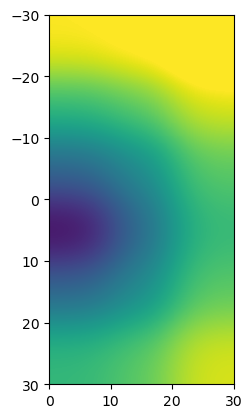

In [22]:
r_grid = np.swapaxes(np.sqrt(x_grid**2 + y_grid**2 + z_grid**2), 0, 1)
m = plt.imshow(r_grid[:,:,0].T, aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 30, interpolation = 'gaussian')

In [ ]:
x = torch.rand((217, model.window, model.in_dim))
position = torch.rand((217, model.pos_dim))
out, h = model.encoder.forward(x)
y_hat = model.decoder.forward(out, position)

In [36]:
out.repeat(3, 1, 1).shape

torch.Size([651, 200, 256])

In [24]:
from models import rff
pos_encoded = rff(position, max_encoding=model.pos_encoding_size)
combined = torch.cat([out[:,-1,:], pos_encoded], dim=-1)
model.decoder.network(combined).shape

torch.Size([217, 4])